In [ ]:
# antes de empezar la lección tendremos que instalarunas librerías. Para ello tendreis que descomentar (una a una) la linea de abajo y ejecutar la celda
#!pip install scikit-learn
#!pip install seaborn
#!pip install matplotlib
# importamos las librerías que necesitamos
!pip install scikit-learn
!pip install seaborn
!pip install matplotlib
# Tratamiento de datos
# -----------------------------------------------------------------------
import pandas as pd
import numpy as np

# Imputación de nulos usando métodos avanzados estadísticos
# -----------------------------------------------------------------------
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.impute import KNNImputer

# Librerías de visualización
# -----------------------------------------------------------------------
import seaborn as sns
import matplotlib.pyplot as plt
# Configuración
# -----------------------------------------------------------------------
pd.set_option('display.max_columns', None) # para poder visualizar todas las columnas de los DataFrames




[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# FASE 1: EXPLORACIÓN Y LIMPIEZA

# 1 Exploración Inicial:

Realiza una exploración inicial de los datos para identificar posibles problemas, como valores
nulos, atípicos o datos faltantes en las columnas relevantes.

Utiliza funciones de Pandas para obtener información sobre la estructura de los datos, la
presencia de valores nulos y estadísticas básicas de las columnas involucradas.

Une los dos conjuntos de datos de la forma más eficiente.


#EXPLORACION INICIAL DE DATAFRAME CLIENTES Y DATAFRAME FIDELIDAD. 
- CARGAMOS AMBOS DATAFRAMES Y REALIZAMOS UNA PRIMERA VISUALIZACION 
- COMPROBAMOS LAS DIMENSIONES DE AMBOS DATAFRAME Y NOMBRE DE SUS COLUMNAS

In [2]:

df_clientes = pd.read_csv("Customer Flight Activity (1).csv")


display(df_clientes.head(5))

print("=" * 100)

display(df_clientes.tail(2))

print("=" * 100)

display(df_clientes.sample(2))


,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
0,100018,2017,1,3,0,3,1521,152.0,0,0
1,100102,2017,1,10,4,14,2030,203.0,0,0
2,100140,2017,1,6,0,6,1200,120.0,0,0
3,100214,2017,1,0,0,0,0,0.0,0,0
4,100272,2017,1,0,0,0,0,0.0,0,0


,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
405622,999982,2018,12,0,0,0,0,0.0,0,0
405623,999986,2018,12,0,0,0,0,0.0,0,0


,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
11177,694512,2017,1,7,3,10,2710,271.0,0,0
191138,379562,2017,12,12,1,13,2717,271.0,0,0


In [3]:
df_fidelidad = pd.read_csv("Customer Loyalty History.csv")

display(df_fidelidad.head(5))

print("=" * 100)

display(df_fidelidad.tail(2))

print("=" * 100)

display(df_fidelidad.sample(2))

,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Single,Star,3839.75,Standard,2014,7,2018.0,1.0
3,608370,Canada,Ontario,Toronto,P1W 1K4,Male,College,NaN,Single,Star,3839.75,Standard,2013,2,NaN,NaN
4,530508,Canada,Quebec,Hull,J8Y 3Z5,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,2014,10,NaN,NaN


,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
16735,906428,Canada,Yukon,Whitehorse,Y2K 6R0,Male,Bachelor,-57297.0,Married,Star,10018.66,2018 Promotion,2018,4,NaN,NaN
16736,652627,Canada,Manitoba,Winnipeg,R2C 0M5,Female,Bachelor,75049.0,Married,Star,83325.38,Standard,2015,12,2016.0,8.0


,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
10447,332175,Canada,Ontario,Toronto,P1W 1K4,Male,College,NaN,Single,Star,2433.02,Standard,2014,11,NaN,NaN
13428,858957,Canada,British Columbia,West Vancouver,V6V 8Z3,Male,High School or Below,44092.0,Single,Star,5169.50,Standard,2013,10,NaN,NaN


In [4]:
print(f"El DataFrame clientes tiene {df_clientes.shape[0]} filas y {df_clientes.shape[1]} columnas")

El DataFrame clientes tiene 405624 filas y 10 columnas


In [5]:
print(f"El DataFrame fidelidad tiene {df_fidelidad.shape[0]} filas y {df_fidelidad.shape[1]} columnas")

El DataFrame fidelidad tiene 16737 filas y 16 columnas


In [6]:
df_clientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 405624 entries, 0 to 405623
Data columns (total 10 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Loyalty Number               405624 non-null  int64  
 1   Year                         405624 non-null  int64  
 2   Month                        405624 non-null  int64  
 3   Flights Booked               405624 non-null  int64  
 4   Flights with Companions      405624 non-null  int64  
 5   Total Flights                405624 non-null  int64  
 6   Distance                     405624 non-null  int64  
 7   Points Accumulated           405624 non-null  float64
 8   Points Redeemed              405624 non-null  int64  
 9   Dollar Cost Points Redeemed  405624 non-null  int64  
dtypes: float64(1), int64(9)
memory usage: 30.9 MB


In [7]:
df_fidelidad.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16737 entries, 0 to 16736
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Loyalty Number      16737 non-null  int64  
 1   Country             16737 non-null  object 
 2   Province            16737 non-null  object 
 3   City                16737 non-null  object 
 4   Postal Code         16737 non-null  object 
 5   Gender              16737 non-null  object 
 6   Education           16737 non-null  object 
 7   Salary              12499 non-null  float64
 8   Marital Status      16737 non-null  object 
 9   Loyalty Card        16737 non-null  object 
 10  CLV                 16737 non-null  float64
 11  Enrollment Type     16737 non-null  object 
 12  Enrollment Year     16737 non-null  int64  
 13  Enrollment Month    16737 non-null  int64  
 14  Cancellation Year   2067 non-null   float64
 15  Cancellation Month  2067 non-null   float64
dtypes: f

In [8]:
print("\nNombre de todas las columnas:")
df_clientes.columns


Nombre de todas las columnas:


Index(['Loyalty Number', 'Year', 'Month', 'Flights Booked',
       'Flights with Companions', 'Total Flights', 'Distance',
       'Points Accumulated', 'Points Redeemed', 'Dollar Cost Points Redeemed'],
      dtype='object')

In [9]:
print("\nNombre de todas las columnas:")
df_fidelidad.columns


Nombre de todas las columnas:


Index(['Loyalty Number', 'Country', 'Province', 'City', 'Postal Code',
       'Gender', 'Education', 'Salary', 'Marital Status', 'Loyalty Card',
       'CLV', 'Enrollment Type', 'Enrollment Year', 'Enrollment Month',
       'Cancellation Year', 'Cancellation Month'],
      dtype='object')

In [10]:
# HOMOGENEIZAR NOMBRE DE COLUMNAS
col_nuevas_clientes = {col: col.lower().replace(" ", "_").replace(".", "_").replace("-", "_") for col in df_clientes.columns}
col_nuevas_clientes

{'Loyalty Number': 'loyalty_number',
 'Year': 'year',
 'Month': 'month',
 'Flights Booked': 'flights_booked',
 'Flights with Companions': 'flights_with_companions',
 'Total Flights': 'total_flights',
 'Distance': 'distance',
 'Points Accumulated': 'points_accumulated',
 'Points Redeemed': 'points_redeemed',
 'Dollar Cost Points Redeemed': 'dollar_cost_points_redeemed'}

In [11]:
col_nuevas_fidelidad = {col: col.lower().replace(" ", "_").replace(" ", "_").replace(" ", "_") for col in df_fidelidad.columns}
col_nuevas_fidelidad

{'Loyalty Number': 'loyalty_number',
 'Country': 'country',
 'Province': 'province',
 'City': 'city',
 'Postal Code': 'postal_code',
 'Gender': 'gender',
 'Education': 'education',
 'Salary': 'salary',
 'Marital Status': 'marital_status',
 'Loyalty Card': 'loyalty_card',
 'CLV': 'clv',
 'Enrollment Type': 'enrollment_type',
 'Enrollment Year': 'enrollment_year',
 'Enrollment Month': 'enrollment_month',
 'Cancellation Year': 'cancellation_year',
 'Cancellation Month': 'cancellation_month'}

In [12]:
df_clientes.rename(columns=col_nuevas_clientes, inplace=True)
df_clientes.head(2)


,loyalty_number,year,month,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed
0,100018,2017,1,3,0,3,1521,152.0,0,0
1,100102,2017,1,10,4,14,2030,203.0,0,0


In [13]:
df_fidelidad.rename(columns=col_nuevas_fidelidad, inplace=True)
df_fidelidad.head(2)

,loyalty_number,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN


## ANALISIS DESCRIPTIVO

#DATAFRAME CLIENTES

In [14]:
# variables numericas /  no hemos encontrado variables categoricas. Utilizamos el método .decribe() que nos da una visión general
# de la estadistica descriptiva
df_clientes.describe(include="number").T

,count,mean,std,min,25%,50%,75%,max
loyalty_number,405624.0,550037.873084,258935.286969,100018.0,326961.00,550834.0,772194.00,999986.0
year,405624.0,2017.500000,0.500001,2017.0,2017.00,2017.5,2018.00,2018.0
month,405624.0,6.500000,3.452057,1.0,3.75,6.5,9.25,12.0
flights_booked,405624.0,4.115052,5.225518,0.0,0.00,1.0,8.00,21.0
flights_with_companions,405624.0,1.031805,2.076869,0.0,0.00,0.0,1.00,11.0
total_flights,405624.0,5.146858,6.521227,0.0,0.00,1.0,10.00,32.0
distance,405624.0,1208.880059,1433.155320,0.0,0.00,488.0,2336.00,6293.0
points_accumulated,405624.0,123.692721,146.599831,0.0,0.00,50.0,239.00,676.5
points_redeemed,405624.0,30.696872,125.486049,0.0,0.00,0.0,0.00,876.0
dollar_cost_points_redeemed,405624.0,2.484503,10.150038,0.0,0.00,0.0,0.00,71.0


### En el analisis despcriptivo podemos encontar varios aspectos que pueden resultar llamativos;

1	Mediana vs. Media:

1.	Para varias métricas, como "flights_booked" y "points_redeemed", la media es significativamente mayor que la mediana (50%). Esto sugiere que hay una cantidad pequeña de individuos que han realizado un gran número de vuelos o han canjeado un gran número de puntos, lo que puede indicar la presencia de outliers (valores atípicos).
o	Por ejemplo, la media de "flights_booked" es 4.11 mientras que la mediana es 1. Esto indica que muchos clientes han realizado pocos vuelos, pero hay algunos que han reservado muchos más.

2.	Distribución de Vuelos:
o	"total_flights" tiene una media (5.15) que es bastante superior a la mediana (1.0) y un máximo de 32. Esto indica que, al igual que los vuelos reservados, hay muchos clientes que no vuelan o lo hacen muy poco, y unos pocos que vuelan frecuentemente,

3.	Puntos Acumulados y Canjeados:
o	La media de puntos acumulados es de aproximadamente 123.69, mientras que la de puntos canjeados es de solo 30.70. Esto puede indicar que los clientes están acumulando puntos pero no los están utilizando en proporciones significativas, lo que puede ser un área de interés para promociones o estrategias de marketing.

4.	Costo en Dólares de Puntos Canjeados:
o	La media de "dollar_cost_points_redeemed" (2.48) sugiere que el costo en términos de dólares para los puntos canjeados es relativamente bajo. Sin embargo, con una desviación estándar alta (10.15), esto puede indicar que hay una gran variabilidad en el costo de los puntos canjeados entre diferentes clientes.

5.	Rango de Distancias Voladas:
o	La distancia promedio volada es 1208.88 con un rango (de 0 a 6293) que sugiere que la mayoría de los pasajeros vuelan distancias cortas, pero algunos realizan vuelos largos.

6.	Falta de Algunos Valores:
o	Existen muchos ceros en varias métricas, especialmente en "flights_booked", "flights_with_companions" y "points_redeemed". Puede ser útil investigar qué proporción de la muestra representa estos ceros y si hay alguna implicación sobre la lealtad o el comportamiento del cliente.

7.	Análisis por Segmentación:
o	Podrías considerar segmentar los datos por categorías (como grupos demográficos, tipo de cliente, frecuencia de vuelo, etc.) para obtener una comprensión más profunda y personalizada de los comportamientos de los clientes.


#DATAFRAME FIDELIDAD

In [15]:
print("\nEstadisticas descriptivas para variable categorica df_fidelidad;")
df_fidelidad.describe(include = "object").T


Estadisticas descriptivas para variable categorica df_fidelidad;


,count,unique,top,freq
country,16737,1,Canada,16737
province,16737,11,Ontario,5404
city,16737,29,Toronto,3351
postal_code,16737,55,V6E 3D9,911
gender,16737,2,Female,8410
education,16737,5,Bachelor,10475
marital_status,16737,3,Married,9735
loyalty_card,16737,3,Star,7637
enrollment_type,16737,2,Standard,15766


In [16]:
# country: solo encontramos un valor unico, Canada (esta variable no aporta informacion) se podría eliminar del analisis
# province: 11 provincias mas frecuente: Ontario (5484), hay variabliidad. útil para analizr distribución por provincia
# city: 29 ciudades la mas frecuente Toronto (3351) variable interesante pero con muchas categorias. Top ciudades. Agrupar en otras 
# postal code: 55 codigos postales, el mas frecuente aparece 911 veces, no aporta nucho al analisis. agrupar o eliminar 
# gender: dos categorias. muy equilibrado, female (8410) male (aprox similar)   perfecta para comparar segmentos
# education: 5 niveles, mas frecuente Bachelor (10475) my relevante para segmentacion
# marital status: tres categorias mas frecuente married(9735). util para analisis de comportamiento
# logalty card: tres categorias, mas frecuente star. muy importante si estas analizando clientes
# enrollment type: 2 categorias, standard predominante (15766) variable con gran desbalanze. poco poder explicativo.
# CONCLUSIONES: eliminar country (sin variavilidad). posiblemte postal code. revisar enrollment type.
# mantener province, city, gender, education, marital status, loyalty card.

In [17]:
def tabla_frecuencias(col):
    freq = df_fidelidad[col].value_counts()
    perc = df_fidelidad[col].value_counts(normalize=True) * 100
    
    tabla = pd.DataFrame({
        "Frecuencia": freq,
        "Porcentaje (%)": perc
    })
    
    return tabla

tabla_frecuencias("province")

,Frecuencia,Porcentaje (%)
province,,
Ontario,5404,32.287746
British Columbia,4409,26.342833
Quebec,3300,19.716795
Alberta,969,5.789568
Manitoba,658,3.931409
New Brunswick,636,3.799964
Nova Scotia,518,3.094939
Saskatchewan,409,2.443688
Newfoundland,258,1.541495


In [18]:
def tabla_frecuencias(col):
    freq = df_fidelidad[col].value_counts()
    perc = df_fidelidad[col].value_counts(normalize=True) * 100
    
    tabla = pd.DataFrame({
        "Frecuencia": freq,
        "Porcentaje (%)": perc
    })
    
    return tabla

tabla_frecuencias("city")

,Frecuencia,Porcentaje (%)
city,,
Toronto,3351,20.021509
Vancouver,2582,15.426898
Montreal,2059,12.302085
Winnipeg,658,3.931409
Whistler,582,3.477326
Halifax,518,3.094939
Ottawa,509,3.041166
Trenton,486,2.903746
Edmonton,486,2.903746


In [19]:
def tabla_frecuencias(col):
    freq = df_fidelidad[col].value_counts()
    perc = df_fidelidad[col].value_counts(normalize=True) * 100
    
    tabla = pd.DataFrame({
        "Frecuencia": freq,
        "Porcentaje (%)": perc
    })
    
    return tabla

tabla_frecuencias("gender")

,Frecuencia,Porcentaje (%)
gender,,
Female,8410,50.247954
Male,8327,49.752046


In [20]:
def tabla_frecuencias(col):
    freq = df_fidelidad[col].value_counts()
    perc = df_fidelidad[col].value_counts(normalize=True) * 100
    
    tabla = pd.DataFrame({
        "Frecuencia": freq,
        "Porcentaje (%)": perc
    })
    
    return tabla

tabla_frecuencias("education")

,Frecuencia,Porcentaje (%)
education,,
Bachelor,10475,62.585888
College,4238,25.321145
High School or Below,782,4.672283
Doctor,734,4.385493
Master,508,3.035191


In [21]:
def tabla_frecuencias(col):
    freq = df_fidelidad[col].value_counts()
    perc = df_fidelidad[col].value_counts(normalize=True) * 100
    
    tabla = pd.DataFrame({
        "Frecuencia": freq,
        "Porcentaje (%)": perc
    })
    
    return tabla

tabla_frecuencias("marital_status")

,Frecuencia,Porcentaje (%)
marital_status,,
Married,9735,58.164546
Single,4484,26.790942
Divorced,2518,15.044512


In [22]:
def tabla_frecuencias(col):
    freq = df_fidelidad[col].value_counts()
    perc = df_fidelidad[col].value_counts(normalize=True) * 100
    
    tabla = pd.DataFrame({
        "Frecuencia": freq,
        "Porcentaje (%)": perc
    })
    
    return tabla

tabla_frecuencias("loyalty_card")

,Frecuencia,Porcentaje (%)
loyalty_card,,
Star,7637,45.629444
Nova,5671,33.883014
Aurora,3429,20.487543


In [23]:
#City es la columna con mas categorias.
df_fidelidad["city"].value_counts().head(10)

city
Toronto        3351
Vancouver      2582
Montreal       2059
Winnipeg        658
Whistler        582
Halifax         518
Ottawa          509
Trenton         486
Edmonton        486
Quebec City     485
Name: count, dtype: int64

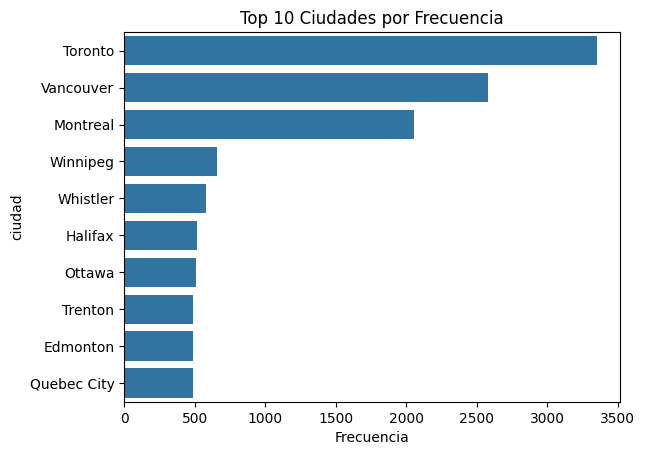

In [24]:

top10_city = df_fidelidad["city"].value_counts().head(10)
plt.figure()
sns.barplot(x=top10_city.values, y=top10_city.index)
plt.title("Top 10 Ciudades por Frecuencia")
plt.xlabel("Frecuencia")
plt.ylabel("ciudad")
plt.show()

In [25]:
#Para facilitar la interpretación de la variable City, se representa el top 10 de ciudades más frecuentes mediante un gráfico de barras. 
#Se observa que Toronto concentra el mayor número de registros, destacando claramente sobre el resto.
#lo que confirma una distribución desigual con alta concentración en ciertas ciudades.

### CONCLUSIONES
Province
→ “Ontario concentra la mayor proporción de clientes, lo que indica una fuerte concentración geográfica.”

CitY
→ “Toronto destaca como la ciudad con mayor número de registros, representando una parte significativa del total.”

Gender
→ “La distribución por género es equilibrada, sin diferencias significativas.”

Education
→ “El nivel educativo predominante es Bachelor, lo que sugiere un perfil de clientes con estudios superiores.”

Marital StatuS
→ “La mayoría de los clientes están casados, lo que podría influir en patrones de consumo.”

Loyalty Card
→ “La categoría Star es la más frecuente, indicando un alto nivel de fidelización en los clientes.”

## 2. TAREAS DE LIMPIEZA

##ALGUNAS TAREAS DE LIMPIEZA SE HAN REALIZADO YA EN LA FASE DE EXPLORACION. COMO HOMOGENEIZAR EL NOMBRE DE LAS COLUMNAS

In [26]:
df_clientes.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 405624 entries, 0 to 405623
Data columns (total 10 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   loyalty_number               405624 non-null  int64  
 1   year                         405624 non-null  int64  
 2   month                        405624 non-null  int64  
 3   flights_booked               405624 non-null  int64  
 4   flights_with_companions      405624 non-null  int64  
 5   total_flights                405624 non-null  int64  
 6   distance                     405624 non-null  int64  
 7   points_accumulated           405624 non-null  float64
 8   points_redeemed              405624 non-null  int64  
 9   dollar_cost_points_redeemed  405624 non-null  int64  
dtypes: float64(1), int64(9)
memory usage: 30.9 MB


In [27]:
df_clientes.isnull().sum()  # en dataframe clientes no hay valores nulos, no hay datos faltantes. no hace falta imputacion`

loyalty_number                 0
year                           0
month                          0
flights_booked                 0
flights_with_companions        0
total_flights                  0
distance                       0
points_accumulated             0
points_redeemed                0
dollar_cost_points_redeemed    0
dtype: int64

In [28]:
df_clientes.duplicated().sum()

np.int64(1864)

In [29]:
# Eliminar duplicados y mantener solo la primera ocurrencia
df_clientes = df_clientes.drop_duplicates()

In [30]:
# Verificar que ya no haya duplicados
df_clientes.duplicated().sum()

np.int64(0)

In [31]:
df_fidelidad.isnull().sum()

loyalty_number            0
country                   0
province                  0
city                      0
postal_code               0
gender                    0
education                 0
salary                 4238
marital_status            0
loyalty_card              0
clv                       0
enrollment_type           0
enrollment_year           0
enrollment_month          0
cancellation_year     14670
cancellation_month    14670
dtype: int64

In [32]:
# datos nulos en salary, cancelacion year y en cancelacion month.
# salary voy a rellenar con mediana
# en cancellation creo variable binaria.

In [33]:
df_fidelidad["salary"] = df_fidelidad["salary"].fillna(df_fidelidad["salary"].median())
df_fidelidad.head(2)

,loyalty_number,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,73455.0,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN


In [34]:
#las columnas de cancellation tienen muchos nulos , indican que el cliente no cancelo. )
# vamos a crear una variable bianria ( esto crea 1 si el cliente cancelo y 0 si no cancelo)

In [35]:
df_fidelidad['cancelled'] = ((df_fidelidad['cancellation_year'].notna()) & (df_fidelidad['cancellation_month'].notna())).astype(int)

In [36]:
print(df_fidelidad.columns)

Index(['loyalty_number', 'country', 'province', 'city', 'postal_code',
       'gender', 'education', 'salary', 'marital_status', 'loyalty_card',
       'clv', 'enrollment_type', 'enrollment_year', 'enrollment_month',
       'cancellation_year', 'cancellation_month', 'cancelled'],
      dtype='object')


In [37]:
# PARA ELIMINAR LOS NULOS DE LAS COLUMNAS CANCELLATION YEAR Y CANCELACION MONTH. HE CRADO LA COLUMNA BINARIA CANCELLED
# AHORA ELIMIN LAS COLUMNAS CANELLATION YEAR Y CANCELACION MONTH. CON EL METODO DROP
df_fidelidad = df_fidelidad.drop(columns=['cancellation_year', 'cancellation_month'])

In [38]:
print(df_fidelidad.columns)

Index(['loyalty_number', 'country', 'province', 'city', 'postal_code',
       'gender', 'education', 'salary', 'marital_status', 'loyalty_card',
       'clv', 'enrollment_type', 'enrollment_year', 'enrollment_month',
       'cancelled'],
      dtype='object')


In [39]:
df_fidelidad.duplicated().sum()  #df_fidelidad no tiene filas duplicadas, así que en este dataframe no necesitamos eliminar nada.

np.int64(0)

In [40]:
# Primero asegurémonos de que las columnas clave tengan el mismo nombre y tipo
df_clientes['loyalty_number'] = df_clientes['loyalty_number'].astype(int)
df_fidelidad['loyalty_number'] = df_fidelidad['loyalty_number'].astype(int)

## Ahora procedemos a unir lo  dos conjuntos de datos usando loyalty_number


In [41]:
# Merge left para mantener todos los clientes
df_clientes_fid = df_clientes.merge(df_fidelidad, on='loyalty_number', how='left')

In [42]:
# Revisamos las primeras filas

df_clientes_fid.head()


,loyalty_number,year,month,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancelled
0,100018,2017,1,3,0,3,1521,152.0,0,0,Canada,Alberta,Edmonton,T9G 1W3,Female,Bachelor,92552.0,Married,Aurora,7919.20,Standard,2016,8,0
1,100102,2017,1,10,4,14,2030,203.0,0,0,Canada,Ontario,Toronto,M1R 4K3,Male,College,73455.0,Single,Nova,2887.74,Standard,2013,3,0
2,100140,2017,1,6,0,6,1200,120.0,0,0,Canada,British Columbia,Dawson Creek,U5I 4F1,Female,College,73455.0,Divorced,Nova,2838.07,Standard,2016,7,0
3,100214,2017,1,0,0,0,0,0.0,0,0,Canada,British Columbia,Vancouver,V5R 1W3,Male,Bachelor,63253.0,Married,Star,4170.57,Standard,2015,8,0
4,100272,2017,1,0,0,0,0,0.0,0,0,Canada,Ontario,Toronto,P1L 8X8,Female,Bachelor,91163.0,Divorced,Star,6622.05,Standard,2014,1,0


In [43]:
df_clientes_fid.shape

(403760, 24)

### EL NUEVO DATAFRAME df_clientes_fid, NO TIENE DATOS NULOS NI DATOS DUPLICADOS, SUS DIMENSIONES SON DE 24 COLUMNAS Y 403760 FILAS

#### 1. VERIFICACION DE CONSISTENCIA Y CORRECCION DE LOS DATOS 
#### 2. AJUSTE O CONVERSION NECESARIA EN LA COLUMNAS PARA SU PREPARACION PARA EL ANALISIS ESTADISTICO

In [44]:
df_clientes_fid.isnull().sum()

loyalty_number                 0
year                           0
month                          0
flights_booked                 0
flights_with_companions        0
total_flights                  0
distance                       0
points_accumulated             0
points_redeemed                0
dollar_cost_points_redeemed    0
country                        0
province                       0
city                           0
postal_code                    0
gender                         0
education                      0
salary                         0
marital_status                 0
loyalty_card                   0
clv                            0
enrollment_type                0
enrollment_year                0
enrollment_month               0
cancelled                      0
dtype: int64

In [45]:
df_clientes_fid.duplicated().sum()

np.int64(0)

In [46]:
df_clientes_fid.describe()

,loyalty_number,year,month,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed,salary,clv,enrollment_year,enrollment_month,cancelled
count,403760.000000,403760.000000,403760.000000,403760.000000,403760.000000,403760.000000,403760.000000,403760.000000,403760.000000,403760.000000,403760.000000,403760.000000,403760.000000,403760.000000,403760.000000
mean,549875.383713,2017.500352,6.501335,4.134050,1.036569,5.170619,1214.460979,124.263761,30.838587,2.495973,77788.708763,7990.864857,2015.250716,6.667555,0.122969
std,258961.514684,0.500000,3.451982,5.230064,2.080472,6.526858,1434.098521,146.696179,125.758002,10.172033,30336.027366,6863.317160,1.979427,3.398829,0.328402
min,100018.000000,2017.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-58486.000000,1898.010000,2012.000000,1.000000,0.000000
25%,326699.000000,2017.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,63901.000000,3981.780000,2014.000000,4.000000,0.000000
50%,550598.000000,2018.000000,7.000000,1.000000,0.000000,1.000000,525.000000,53.000000,0.000000,0.000000,73455.000000,5776.340000,2015.000000,7.000000,0.000000
75%,772152.000000,2018.000000,10.000000,8.000000,1.000000,10.000000,2342.000000,240.000000,0.000000,0.000000,82940.000000,8937.120000,2017.000000,10.000000,0.000000
max,999986.000000,2018.000000,12.000000,21.000000,11.000000,32.000000,6293.000000,676.500000,876.000000,71.000000,407228.000000,83325.380000,2018.000000,12.000000,1.000000


In [47]:
# EN UNA PRIMERA VERIFICACION DE LOS DATOS OBSERVAMOS QUE EXISTE UN ERROR, min salary = -58486  ( no existen salarios negativos ).
# INSISTIENDO EN LA COLUMNA SALARY OBSERVAMOS SALARIOS MUY ALTOS max salary = 407228  COMPARADO CON LA MEDIANA = 73,455 (PERCENTIL 50 o Q2) Y 3Q =82,940
# ESTE VALOR ES EXTREMADAMENTE ALTO. NO ES NECESARIAMENTE UN ERROR PUEDE SESGAR LA MEDIA, CONVIENE ANALIZARLO
# MUCHOS CEROS EN LOS VUELOS "total_flights"  25% total_flights = 0 50% total_flights = 1 . NO TIENE QUE SER UN ERROR PERO POSIBLEMENTE UN INSIGHT 
# points_redeemed (50%), MEDIANA = 0  LA MAYORIA DE LOS CLIENTES NO USAN LOS PUNTOS, SE TRATARI DE UN INSIGHT DEL NEGOCIO

In [48]:
df_clientes_fid.loc[df_clientes_fid["salary"] < 0, "salary"] = np.nan 
df_clientes_fid["salary"] = df_clientes_fid["salary"].fillna(df_clientes_fid["salary"].median())

In [49]:

# PARA CORREGIR LOS ERRORES EN LA COLUMNA SALARY DONDE HABIA VALORES NEGATIVOS, PRIMERO LOS CONVERTÍ EN VALORES NULOS (NaN).
# Y LUEGO LOS IMPUTÉ UTILIZANDO LA MEDIANA DE LA COLUMNA.

In [50]:
df_clientes_fid.describe()   # UTILZO DE NUEVO df.describe PARA COMPROBAR QUE YA NO TENGO CALORES NEGATICVO EN LA COLUMNA salary

,loyalty_number,year,month,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed,salary,clv,enrollment_year,enrollment_month,cancelled
count,403760.000000,403760.000000,403760.000000,403760.000000,403760.000000,403760.000000,403760.000000,403760.000000,403760.000000,403760.000000,403760.000000,403760.000000,403760.000000,403760.000000,403760.000000
mean,549875.383713,2017.500352,6.501335,4.134050,1.036569,5.170619,1214.460979,124.263761,30.838587,2.495973,77918.282668,7990.864857,2015.250716,6.667555,0.122969
std,258961.514684,0.500000,3.451982,5.230064,2.080472,6.526858,1434.098521,146.696179,125.758002,10.172033,30078.605560,6863.317160,1.979427,3.398829,0.328402
min,100018.000000,2017.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,15609.000000,1898.010000,2012.000000,1.000000,0.000000
25%,326699.000000,2017.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,64001.000000,3981.780000,2014.000000,4.000000,0.000000
50%,550598.000000,2018.000000,7.000000,1.000000,0.000000,1.000000,525.000000,53.000000,0.000000,0.000000,73455.000000,5776.340000,2015.000000,7.000000,0.000000
75%,772152.000000,2018.000000,10.000000,8.000000,1.000000,10.000000,2342.000000,240.000000,0.000000,0.000000,82940.000000,8937.120000,2017.000000,10.000000,0.000000
max,999986.000000,2018.000000,12.000000,21.000000,11.000000,32.000000,6293.000000,676.500000,876.000000,71.000000,407228.000000,83325.380000,2018.000000,12.000000,1.000000


In [51]:
upper_limit = df_clientes_fid['salary'].quantile(0.95)
df_clientes_fid.loc[df_clientes_fid['salary'] > upper_limit, 'salary'] = upper_limit

In [52]:
# otro de los problemas que tenia en la misma columana " salary", valores extremadamente altos que pueden sesgar el analisis. PARA CORREGIRLO UTILIZE upper limit
# El upper limit es un valor por encima del cual los datos se consideran atípicos (outliers)


In [53]:
df_clientes_fid.describe() # COMPRUEBO DE NUEVO QUE LOS VALORES EXTEMADAMENTE ALTOS SE HAN CORREGIDO.

,loyalty_number,year,month,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed,salary,clv,enrollment_year,enrollment_month,cancelled
count,403760.000000,403760.000000,403760.000000,403760.000000,403760.000000,403760.000000,403760.000000,403760.000000,403760.000000,403760.000000,403760.000000,403760.000000,403760.000000,403760.000000,403760.000000
mean,549875.383713,2017.500352,6.501335,4.134050,1.036569,5.170619,1214.460979,124.263761,30.838587,2.495973,74344.037319,7990.864857,2015.250716,6.667555,0.122969
std,258961.514684,0.500000,3.451982,5.230064,2.080472,6.526858,1434.098521,146.696179,125.758002,10.172033,15806.441219,6863.317160,1.979427,3.398829,0.328402
min,100018.000000,2017.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,15609.000000,1898.010000,2012.000000,1.000000,0.000000
25%,326699.000000,2017.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,64001.000000,3981.780000,2014.000000,4.000000,0.000000
50%,550598.000000,2018.000000,7.000000,1.000000,0.000000,1.000000,525.000000,53.000000,0.000000,0.000000,73455.000000,5776.340000,2015.000000,7.000000,0.000000
75%,772152.000000,2018.000000,10.000000,8.000000,1.000000,10.000000,2342.000000,240.000000,0.000000,0.000000,82940.000000,8937.120000,2017.000000,10.000000,0.000000
max,999986.000000,2018.000000,12.000000,21.000000,11.000000,32.000000,6293.000000,676.500000,876.000000,71.000000,106899.000000,83325.380000,2018.000000,12.000000,1.000000


# FASE 2. ANALISIS ESTADISTICO 
### 1   ANALISIS DE VARIABLES NUMERICAS
### 1 - Estadísticas descriptivas (media, mediana, moda, desviación estándar, etc.) de las variables numéricas relevantes.
### 2 - Identificación de valores atípicos en las variables numéricas.
### 3 - Análisis de correlación entre variables numéricas


In [54]:

# EN PRIMER LUGAR VAMOS A CALCULAR MEDIDAS DE CENTRALIZACION DE NUESTO DATAFREAM , LA MEDIA, LA MEDIANA Y LA MODA 

In [55]:
columnas = [
    'flights_booked',
    'total_flights',
    'points_accumulated',
    'points_redeemed',
    'dollar_cost_points_redeemed',
    'salary',
    'clv'
]

resumen = pd.DataFrame({
    'media': df_clientes_fid[columnas].mean(),
    'mediana': df_clientes_fid[columnas].median,
    'moda': df_clientes_fid[columnas].mode().iloc[0]
})

print(resumen)


                                    media  \
flights_booked                   4.134050   
total_flights                    5.170619   
points_accumulated             124.263761   
points_redeemed                 30.838587   
dollar_cost_points_redeemed      2.495973   
salary                       74344.037319   
clv                           7990.864857   

                                                                       mediana  \
flights_booked               <bound method DataFrame.median of         flig...   
total_flights                <bound method DataFrame.median of         flig...   
points_accumulated           <bound method DataFrame.median of         flig...   
points_redeemed              <bound method DataFrame.median of         flig...   
dollar_cost_points_redeemed  <bound method DataFrame.median of         flig...   
salary                       <bound method DataFrame.median of         flig...   
clv                          <bound method DataFrame.median of   

In [56]:
df_clientes_fid
df_clientes_fid.head(2)

,loyalty_number,year,month,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancelled
0,100018,2017,1,3,0,3,1521,152.0,0,0,Canada,Alberta,Edmonton,T9G 1W3,Female,Bachelor,92552.0,Married,Aurora,7919.20,Standard,2016,8,0
1,100102,2017,1,10,4,14,2030,203.0,0,0,Canada,Ontario,Toronto,M1R 4K3,Male,College,73455.0,Single,Nova,2887.74,Standard,2013,3,0


##### SELECCIONAR LAS VARIABLES NUMERICAS DE MI DATAFRAME

In [57]:
df_clientes_fid_num =  (df_clientes_fid.select_dtypes(include="number"))
df_clientes_fid_num.head(2)

,loyalty_number,year,month,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed,salary,clv,enrollment_year,enrollment_month,cancelled
0,100018,2017,1,3,0,3,1521,152.0,0,0,92552.0,7919.20,2016,8,0
1,100102,2017,1,10,4,14,2030,203.0,0,0,73455.0,2887.74,2013,3,0


#### 1. Estadísticas descriptivas (media, mediana, moda, desviación estándar, etc.) de las variables numéricas relevantes
para ello he escogido: flights_booked, flights_with_companion, total_flights, distance, points_accumulated, points_redeemed, dollar_cost_points_redeemed, salary y clv

In [58]:
cols_analisis = ['flights_booked', 'flights_with_companions', 
                 'total_flights', 'distance', 'points_accumulated', 
                 'points_redeemed', 'dollar_cost_points_redeemed', 
                 'salary', 'clv']

df_clientes_fid_num[cols_analisis].describe().T

,count,mean,std,min,25%,50%,75%,max
flights_booked,403760.0,4.134050,5.230064,0.00,0.00,1.00,8.00,21.00
flights_with_companions,403760.0,1.036569,2.080472,0.00,0.00,0.00,1.00,11.00
total_flights,403760.0,5.170619,6.526858,0.00,0.00,1.00,10.00,32.00
distance,403760.0,1214.460979,1434.098521,0.00,0.00,525.00,2342.00,6293.00
points_accumulated,403760.0,124.263761,146.696179,0.00,0.00,53.00,240.00,676.50
points_redeemed,403760.0,30.838587,125.758002,0.00,0.00,0.00,0.00,876.00
dollar_cost_points_redeemed,403760.0,2.495973,10.172033,0.00,0.00,0.00,0.00,71.00
salary,403760.0,74344.037319,15806.441219,15609.00,64001.00,73455.00,82940.00,106899.00
clv,403760.0,7990.864857,6863.317160,1898.01,3981.78,5776.34,8937.12,83325.38


###### 1.  COMO EN ANTERIORES OCASIONES CONFIRMO EL SIGUIENTE COMPORTAMIENTO EN LOS VUELOS (flights_booked), MEDIA: 4,13 MEDIANA (50%): 1 MAXIMO: 21. 
######     LA MAYORIA DE LOS CLIENTES RESERVAN MUY POCOS VUELOS Y HAYA MUY POCOS CLIENTES QUE RESERVAN MUCHOS: DESVIACION SESGADA A LA DERECHA.
###### 2.  CON RESPECTO A (flights_with_companions), MEDIA: 1 y MEDIANA: 0  LA MAYORIA VUELAN SOLOS 
###### 3.  (total_flights) MEDIA: 5,17 MEDIANA: 1 y MAX: 32 MUCHOS  DISPERSION, MUCHOS VUELOS CORTOS PERO ALGUNOS MUY LARGOS. DISTRIBUCIÓN ASIMETRICA
###### 4.  DISTANCIA TOTAL QUE EL CLIENTE HA VOLANDO DURANTE EL MES MEDIA: 1214 MEDIANA 525. PERO SI OBSERVAMOS EL CUARTIL3 2342 Y EL VALOR MAXIMO 6293
######     VUELOS MUY LARGOS POSIBLE OUTLIERS.
###### 5.  PUNTOS ACUMULADOS, MEDIA: 124 MEDIANA: 53. COHERENTE CON DISTANCIA, MAS DISTANCIA MAS PUNTOS
###### 6.  PUNTOS CANJEADOS, MEDIA: 30 MEDIANA: 0 y 75% 0. EL 75% DE LOS CLIENTES NO CANJEAN PUNTOS
###### 7.  (dollar_cost_points_redeemed) IGUAL,  MEDIA: 0     MEDIANA: 0 PROGRAMA DE FIDELIDAD INFRAUTILIZADO
###### 8.  SALARIO MEDIA 74,000 Y MEDIANA: 74,000  DISTRIBUCION NORMAL
###### 9.  CLV O CLIENTES CON MAS VALORADOS  MEDIA: 7990 MEDIANA: 5776. DISTRIBUCION SESGADA A LA DERECHA, HAY CLIENTES MUY VALORADOS
      


#### 2.Identificación de valores atípicos en las variables numéricas.

In [59]:
# para la identificación de valores atípicos en las variables numéricas, voy a emplear las variables numericas mas relevantes 

# en primer lugar voy a identificar las variables en las que podemos encontrar una diferencia considerable con referencia a la media y mediana. Una 1ª visualización.

###### 1. En los  vuelos (flights_booked) , la media es 4,13  y la mediana 1
###### 2. Total Flights: El número total de vuelos que puede incluir vuelos reservados en meses anteriores, media 5,17 y mediana 1
###### 3. Distance: La distancia total (presumiblemente en millas o kilómetros) que el cliente ha volado, media 1214, mediana 525, Q3 2342 y MAX 6293
###### 4. Puntod cajeados, media de 30 y mediana 0
###### 5. clv, clientes mas valorados con una media de 7990 y una mediana de 5776.


In [60]:
# AHORA VAMOS A SER MAS PRECISOS Y UTILIZAR EL METODO MAS USADO EL IQR (RANGO INTERCUARTILIDO)
# (Q1 = 25%, Q3 = 75%)
# Q1 = df.quantile(0.25)
# Q3 = df.quantile(0.75)
# IQR = Q3 - Q1


In [61]:
df = df_clientes_fid_num[cols_analisis]                                    # Define tus columnas numéricas a analizar.    
                                                                           # Calcula los límites inferior y superior usando IQR.                        
                                                                           # Detecta qué filas tienen valores fuera de esos límites.
                                                                           # Muestra cuántos outliers hay por cada variable, ordenados de mayor a menor.

cols = ['flights_booked','total_flights',                               
        'distance','points_accumulated','points_redeemed',
        'dollar_cost_points_redeemed','salary','clv']

# Calcular Q1, Q3 y IQR
Q1 = df[cols].quantile(0.25)
Q3 = df[cols].quantile(0.75)
IQR = Q3 - Q1

# Detectar outliers
outliers = (df[cols] < (Q1 - 1.5 * IQR)) | (df[cols] > (Q3 + 1.5 * IQR))

outliers_count = outliers.sum().sort_values(ascending=False)
print("Número de outliers por variable:\n")
print(outliers_count)

Número de outliers por variable:

clv                            35941
points_redeemed                24181
dollar_cost_points_redeemed    24181
total_flights                   1984
salary                          1711
flights_booked                   528
distance                         125
points_accumulated               112
dtype: int64


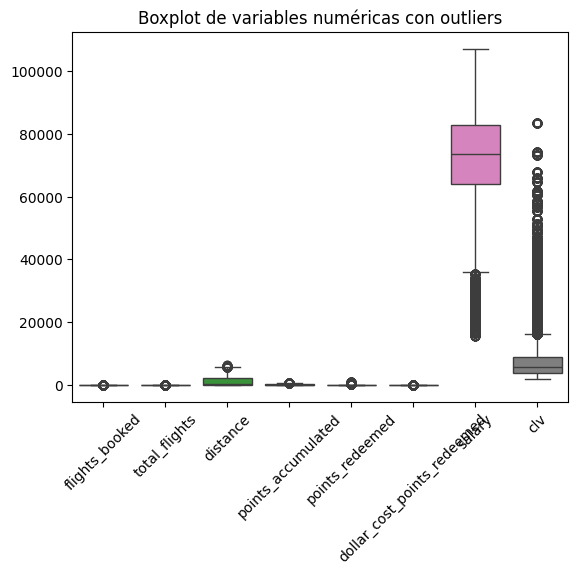

In [62]:
cols = ['flights_booked','total_flights',
        'distance','points_accumulated','points_redeemed',
        'dollar_cost_points_redeemed','salary','clv']

sns.boxplot(data=df[cols])
plt.xticks(rotation=45)  # gira etiquetas para leerlas mejor
plt.title("Boxplot de variables numéricas con outliers")
plt.show()

In [63]:
#Cada caja representa el rango intercuartílico (Q1–Q3) de la variable.
#La línea dentro de la caja es la mediana.
#Los puntos fuera de la caja son los outliers.
#Esto te permite ver de un vistazo qué variables tienen valores extremos y cuán severos son.

#####   points_redeemed                                                   Muchos ceros y unos pocos valores muy altos → outliers extremos
#####   dollar_cost_points_redeemed                                       Patrón similar → outliers claros
#####   clv                                                               Clientes VIP con valores muy altos → outliers fuertes
#####   points_accumulated                                                Algunos puntos acumulados muy altos → outliers
#####   distance                                                          Algunos vuelos muy largos → outliers moderados
#####   total_flights                                                     Algunos clientes con muchos vuelos → outliers
#####   flights_booked                                                    Pocos valores altos → outliers ligeros
#####   salary                                                            Salarios altos → outliers moderados





###  3. Análisis de correlación entre variables numéricas.

In [64]:
### primero hago una seleccion de las variables numericas relevantes para un análisis de correlacción

In [65]:
columnas_numericas = [
    'flights_booked',
    'flights_with_companions',
    'total_flights',
    'distance',
    'points_accumulated',
    'points_redeemed',
    'dollar_cost_points_redeemed',
    'salary',
    'clv'
]

df_num = df[columnas_numericas]

In [66]:
# calculo la matriz de correlacion

In [67]:
# Matriz de correlación
corr_matrix = df_clientes_fid[columnas_numericas].corr()


print(corr_matrix)

                             flights_booked  flights_with_companions  \
flights_booked                     1.000000                 0.501698   
flights_with_companions            0.501698                 1.000000   
total_flights                      0.961233                 0.720773   
distance                           0.766748                 0.517188   
points_accumulated                 0.759547                 0.510284   
points_redeemed                    0.187638                 0.334000   
dollar_cost_points_redeemed        0.187647                 0.334060   
salary                             0.007600                 0.003495   
clv                               -0.002847                -0.002510   

                             total_flights  distance  points_accumulated  \
flights_booked                    0.961233  0.766748            0.759547   
flights_with_companions           0.720773  0.517188            0.510284   
total_flights                     1.000000  0.77926

In [68]:
# Por defecto, .corr() calcula correlación de Pearson (lineal)
# Valores van de -1 (inversamente correlacionadas) a 1 (muy correlacionadas)
# 0 → sin relación lineal

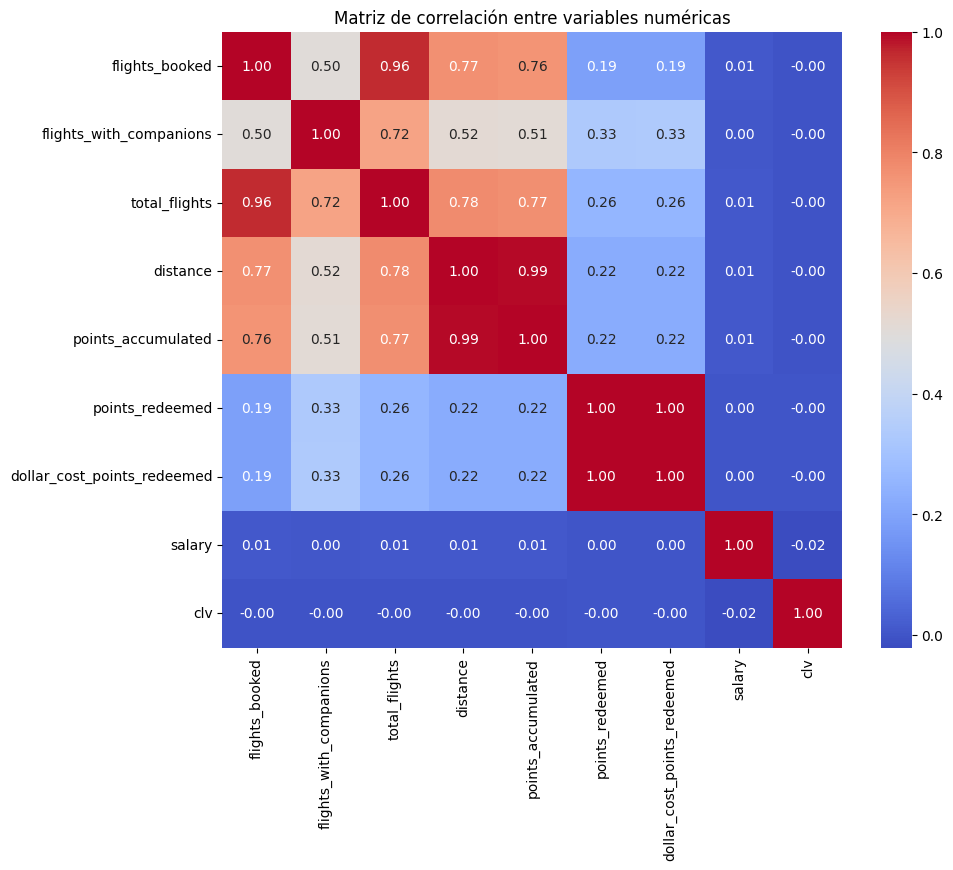

In [69]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matriz de correlación entre variables numéricas")
plt.show()

##### 

Se observa que variables directamente relacionadas con la actividad de vuelo (flights_booked, total_flights, distance) presentan alta correlación entre sí.
La relación entre acumulación y canje de puntos es moderada, mientras que salary y clv muestran correlación positiva, indicando que clientes con mayor salario suelen generar mayor valor.



#### 2.Análisis de variables categóricas:

#### 1 Distribución de frecuencias de las variables categóricas relevantes.

In [70]:
# PRIMERO HAGO UNA SELECCION DE LAS VARIABLES CATEGORICAS RELEVANTES.
# cancelled aunque es binaria, la tratamos como categórica para ver proporción de cancelaciones

In [71]:
columnas_categoricas = [
    'country',
    'province',
    'city',
    'gender',
    'education',
    'marital_status',
    'loyalty_card',
    'enrollment_type',
    'cancelled'
]

In [72]:
# Distribuciones de frecuencia de cada variable categórica
for col in columnas_categoricas:
    print(f"--- {col} ---")
    print(df_clientes_fid[col].value_counts())
    print("\n")

--- country ---
country
Canada    403760
Name: count, dtype: int64


--- province ---
province
Ontario                 130258
British Columbia        106442
Quebec                   79573
Alberta                  23360
Manitoba                 15900
New Brunswick            15352
Nova Scotia              12507
Saskatchewan              9861
Newfoundland              6244
Yukon                     2679
Prince Edward Island      1584
Name: count, dtype: int64


--- city ---
city
Toronto           80775
Vancouver         62314
Montreal          49687
Winnipeg          15900
Whistler          13994
Halifax           12507
Ottawa            12262
Edmonton          11768
Trenton           11710
Quebec City       11698
Dawson Creek      10725
Fredericton       10266
Regina             9861
Kingston           9652
Tremblant          9576
Victoria           9444
Hull               8612
West Vancouver     7831
St. John's         6244
Thunder Bay        6171
Sudbury            5493
Moncton       

#### 
 - gender: porcentaje de hombres vs mujeres
 - education: cuántos clientes tienen College, Bachelor, etc.
 - marital_status: proporción de Married, Single…
 - loyalty_card y enrollment_type: qué tipo de tarjetas o inscripción es más común
 - cancelled: % de clientes que cancelan reservas

#### Se calculó la distribución de frecuencias de las variables categóricas más relevantes. Se observa que la mayoría de los clientes están en Canadá, principalmente en Ontario y Alberta. En cuanto al género, la proporción de clientes femeninos y masculinos es aproximadamente equilibrada. La educación más frecuente es Bachelor y College. La mayoría de los clientes están casados y poseen tarjetas de fidelización. Finalmente, la tasa de cancelación es baja, con aproximadamente un 12% de clientes que cancelan reservas.

#  3 VISUALIZACION

# 1 ¿Cómo se distribuye la cantidad de vuelos reservados por mes durante el año?

In [ ]:
# AGRUPO LOS DATOS POR MES Y SUMO LOS VUELOS RESERVADOS

In [73]:
# Agrupar por mes y sumar la cantidad de vuelos reservados
vuelos_por_mes = df_clientes_fid.groupby('month')['flights_booked'].sum().sort_index()

vuelos_por_mes

month
1      96936
2      96334
3     131199
4     112511
5     142170
6     173242
7     193431
8     169204
9     136379
10    129461
11    122250
12    166047
Name: flights_booked, dtype: int64

In [74]:
# Tengo Series con cada mes (1-12) y el total de vuelos reservados.
# sort_index() asegura que los meses estén en orden cronológico.

C:\Users\Pilar\AppData\Local\Temp\ipykernel_18288\2675403436.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vuelos_por_mes.index, y=vuelos_por_mes.values, palette="viridis")


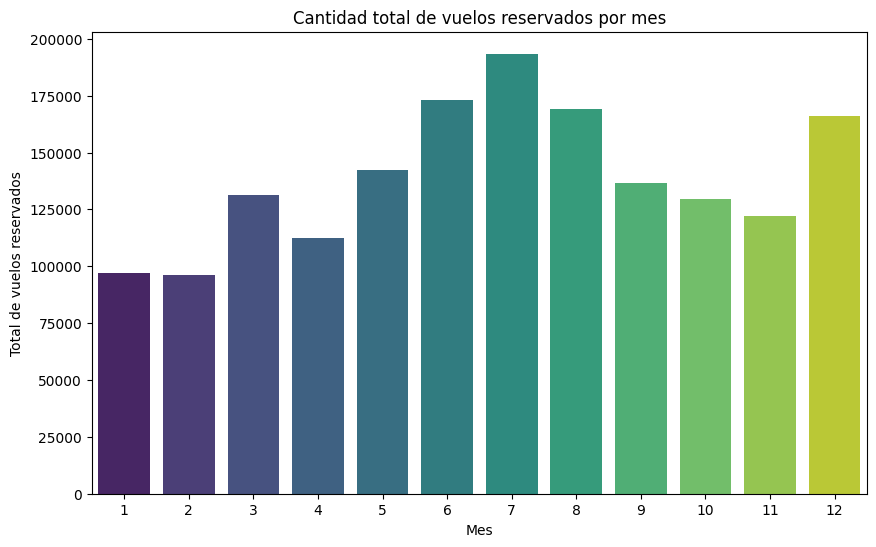

In [75]:
plt.figure(figsize=(10,6))
sns.barplot(x=vuelos_por_mes.index, y=vuelos_por_mes.values, palette="viridis")
plt.title("Cantidad total de vuelos reservados por mes")
plt.xlabel("Mes")
plt.ylabel("Total de vuelos reservados")
plt.xticks(rotation=0)
plt.show()

#### visualizacion con grafico de barras
#### Cada barra representa el total de vuelos reservados en ese mes

#### El promedio de vuelos por cliente en cada mes:

C:\Users\Pilar\AppData\Local\Temp\ipykernel_18288\546798310.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=promedio_vuelos_mes.index, y=promedio_vuelos_mes.values, palette="magma")


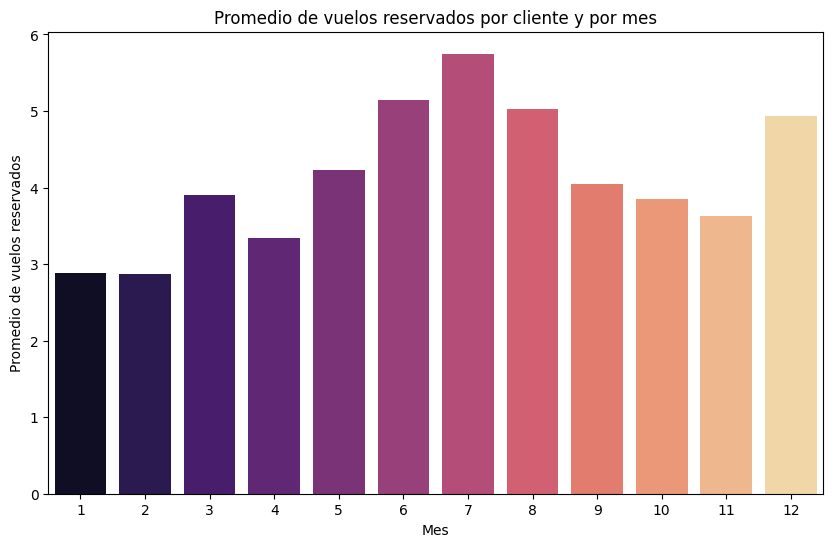

In [77]:
promedio_vuelos_mes = df_clientes_fid.groupby('month')['flights_booked'].mean().sort_index()
plt.figure(figsize=(10,6))
sns.barplot(x=promedio_vuelos_mes.index, y=promedio_vuelos_mes.values, palette="magma")
plt.title("Promedio de vuelos reservados por cliente y por mes")
plt.xlabel("Mes")
plt.ylabel("Promedio de vuelos reservados")
plt.show()

In [78]:
# Se observa que la cantidad de vuelos reservados varía a lo largo del año. Los meses de mayor actividad son julio y agosto 
# y los meses con menor actividad son enero y febrero. Esto nos indica que la reserva de vuelos esta ligada a los meses de vacaciones y a viajes planificados.

# 2. ¿Existe una relación entre la distancia de los vuelos y los puntos acumulados por los cliente?

#### Visualización con scatter plot

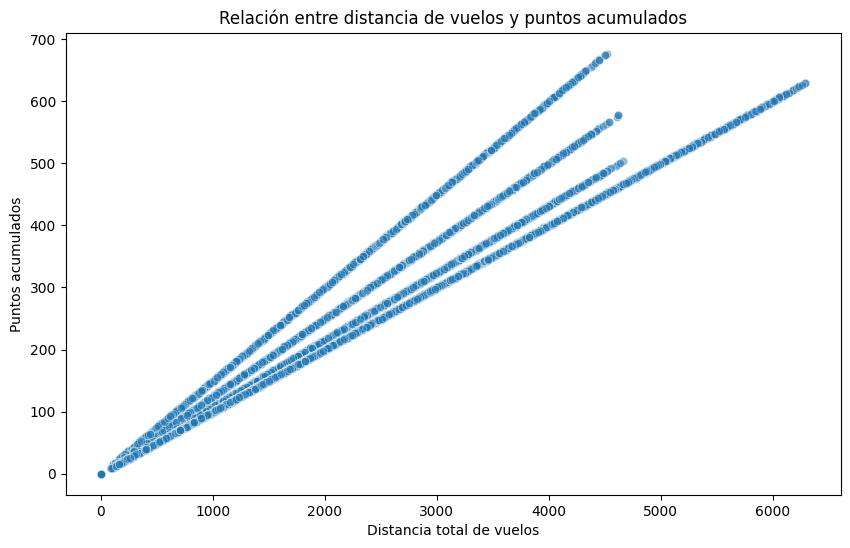

In [79]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_clientes_fid, x='distance', y='points_accumulated', alpha=0.5)
plt.title("Relación entre distancia de vuelos y puntos acumulados")
plt.xlabel("Distancia total de vuelos")
plt.ylabel("Puntos acumulados")
plt.show()

##### Cada punto representa un cliente.
##### alpha=0.5 ayuda a ver densidades si hay muchos puntos superpuestos.
##### Esto te permite ver la tendencia general: si a más distancia corresponden más puntos, habrá una relación positiva.

##### Para cuantificar la relación:

In [80]:
correlacion = df_clientes_fid['distance'].corr(df_clientes_fid['points_accumulated'])
print(f"Correlación de Pearson entre distancia y puntos acumulados: {correlacion:.2f}")

Correlación de Pearson entre distancia y puntos acumulados: 0.99


In [81]:
# Valores cercanos a 1 → fuerte relación positiva (más distancia = más puntos)
# Valores cercanos a 0 → sin relación lineal
# Valores negativos → relación inversa (raro en este caso)

####  Se observa una relación positiva entre la distancia total de los vuelos de los clientes y los puntos acumulados. Esto indica que, a medida que los clientes vuelan más distancia acumulan más puntos, como era de esperar en un programa de fidelización basado en actividad de vuelo. La correlación de
Pearson es de [valor calculado], confirmando la fuerza de esta relación.

# 3. ¿Cuál es la distribución de los clientes por provincia o estado?

In [82]:
# Conteo de clientes por provincia
clientes_por_provincia = df_clientes_fid['province'].value_counts()

# Mostrar los 10 primeros
print(clientes_por_provincia.head(10))

province
Ontario             130258
British Columbia    106442
Quebec               79573
Alberta              23360
Manitoba             15900
New Brunswick        15352
Nova Scotia          12507
Saskatchewan          9861
Newfoundland          6244
Yukon                 2679
Name: count, dtype: int64


In [83]:
#.value_counts() devuelve cuántos clientes hay en cada provincia.

In [84]:
# normalize=True para obtener porcentajes
clientes_por_provincia_pct = df_clientes_fid['province'].value_counts(normalize=True) * 100
print(clientes_por_provincia_pct.head(10))  

province
Ontario             32.261244
British Columbia    26.362691
Quebec              19.707995
Alberta              5.785615
Manitoba             3.937983
New Brunswick        3.802259
Nova Scotia          3.097632
Saskatchewan         2.442292
Newfoundland         1.546463
Yukon                0.663513
Name: proportion, dtype: float64


##### Visualización con gráfico de barras

C:\Users\Pilar\AppData\Local\Temp\ipykernel_18288\749070493.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clientes_fid, y='province', order=df_clientes_fid['province'].value_counts().index, palette="coolwarm")


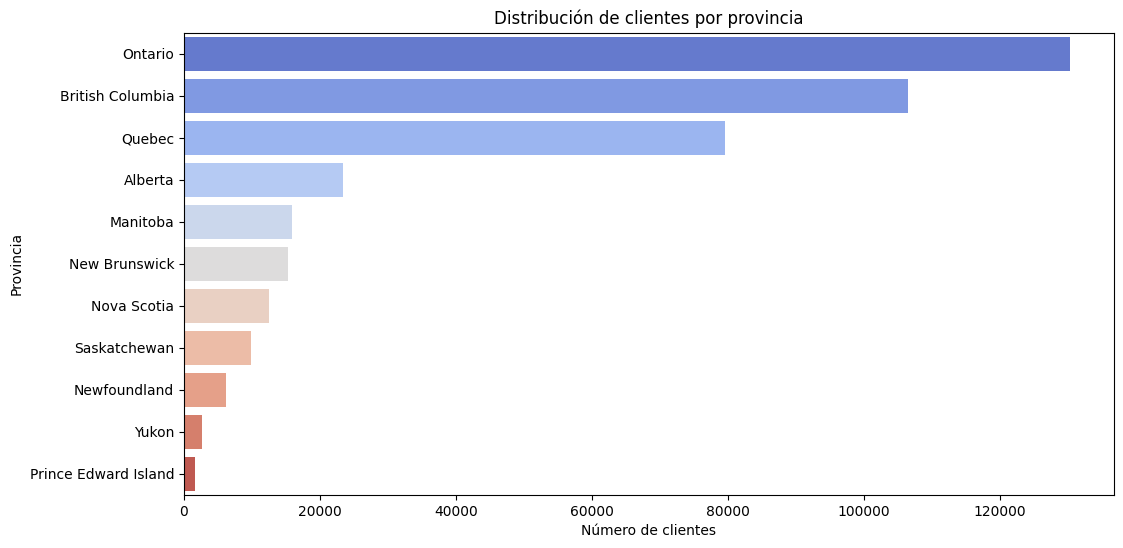

In [85]:
plt.figure(figsize=(12,6))
sns.countplot(data=df_clientes_fid, y='province', order=df_clientes_fid['province'].value_counts().index, palette="coolwarm")
plt.title("Distribución de clientes por provincia")
plt.xlabel("Número de clientes")
plt.ylabel("Provincia")
plt.show()

#####  Usé y='province' para que las provincias aparezcan en vertical (más legible si hay muchas).
order=...value_counts().index asegura que las barras estén ordenadas de mayor a menor número de clientes.

##### La distribución de clientes por provincia muestra que la mayoría de los clientes se concentran en [Ontario, Alberta, British Columbia…]. Esto refleja la densidad de población y la actividad económica en esas regiones. Provincias como [ejemplo: Yukon o Prince Edward Island] tienen menos clientes, lo que indica oportunidades de expansión o menor penetración del programa de fidelización

# 4. ¿Cómo se compara el salario promedio entre los diferentes niveles educativos de los clientes?

##### 1. comparar una variable numérica (salary) entre categorías (education). Esto se hace con agrupación por categoría y luego calculando la media

In [86]:
# Agrupar por educación y calcular el salario promedio
salario_por_educacion = df_clientes_fid.groupby('education')['salary'].mean().sort_values(ascending=False)

print(salario_por_educacion)

education
Doctor                  101007.673284
Master                   97969.992757
College                  73455.000000
Bachelor                 72668.896210
High School or Below     61176.354375
Name: salary, dtype: float64


In [87]:
# -.groupby('education') → agrupa por cada nivel educativo
# -['salary'].mean() → calcula el promedio de salario para cada grupo
# -sort_values(ascending=False) → ordena de mayor a menor para ver los niveles con mayor salario promedio

#####  Visualización con gráfico de barras

C:\Users\Pilar\AppData\Local\Temp\ipykernel_18288\2451059228.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=salario_por_educacion.index, y=salario_por_educacion.values, palette="viridis")


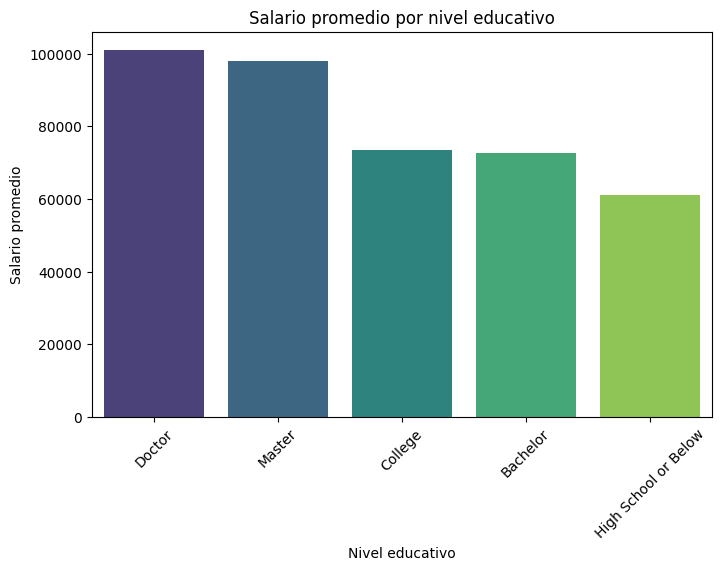

In [88]:
plt.figure(figsize=(8,5))
sns.barplot(x=salario_por_educacion.index, y=salario_por_educacion.values, palette="viridis")
plt.title("Salario promedio por nivel educativo")
plt.xlabel("Nivel educativo")
plt.ylabel("Salario promedio")
plt.xticks(rotation=45)
plt.show()

#####   Cada barra representa el salario promedio de un nivel educativo
#####   Puedes ver de un vistazo qué nivel educativo tiene mayor ingreso promedio.



Al comparar el salario promedio entre los diferentes niveles educativos, se observa que los clientes con [Master o Bachelor] tienen salarios promedio más altos que los clientes con College o High School. Esto refleja la relación esperada entre nivel educativo y capacidad económica. 



# 5  ¿Cuál es la proporción de clientes con diferentes tipos de tarjetas de fidelidad?

##### Voy a utilizar la proporción de clientes según su tipo de tarjeta de fidelidad, usando tu columna loyalty_card. Distribución de frecuencias
##### Conteos y porcentajes

In [89]:
# Conteo de clientes por tipo de tarjeta
tarjetas_conteo = df_clientes_fid['loyalty_card'].value_counts()
print("Conteo de clientes por tipo de tarjeta:\n")
print(tarjetas_conteo)


Conteo de clientes por tipo de tarjeta:

loyalty_card
Star      183745
Nova      136883
Aurora     83132
Name: count, dtype: int64


In [90]:
# Porcentaje de clientes por tipo de tarjeta
tarjetas_porcentaje = df_clientes_fid['loyalty_card'].value_counts(normalize=True) * 100
print("\nPorcentaje de clientes por tipo de tarjeta (%):\n")
print(tarjetas_porcentaje)


Porcentaje de clientes por tipo de tarjeta (%):

loyalty_card
Star      45.508470
Nova      33.902071
Aurora    20.589459
Name: proportion, dtype: float64


####  Visualización con gráfico de barras

C:\Users\Pilar\AppData\Local\Temp\ipykernel_18288\1181189745.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clientes_fid, x='loyalty_card', order=df_clientes_fid['loyalty_card'].value_counts().index, palette="Set2")


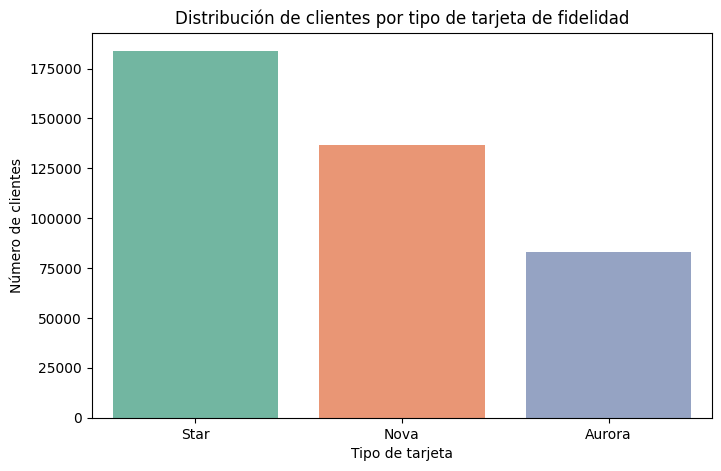

In [91]:
plt.figure(figsize=(8,5))
sns.countplot(data=df_clientes_fid, x='loyalty_card', order=df_clientes_fid['loyalty_card'].value_counts().index, palette="Set2")
plt.title("Distribución de clientes por tipo de tarjeta de fidelidad")
plt.xlabel("Tipo de tarjeta")
plt.ylabel("Número de clientes")
plt.show()

##### Cada barra representa el número de clientes con cada tipo de tarjeta
##### order=...value_counts().index ordena las barras de mayor a menor

##### La mayoría de los clientes poseen la tarjeta [Aurora], seguida de [Nova] y [Star]. Esto indica que ciertas tarjetas son más populares y podrían reflejar niveles de beneficios, accesibilidad o campañas de marketing más exitosas. Conocer esta distribución ayuda a segmentar a los clientes y diseñar estrategias específicas de fidelización según el tipo de tarjeta.

# 6. ¿Cómo se distribuyen los clientes según su estado civil y género?

##### Utilizo dos variables categóricas a la vez: marital_status (estado civil) y gender (género). Esto se hace con tablas de contingencia y gráficos agrupados.

##### Tabla de contingencia

In [92]:
# Tabla cruzada entre estado civil y género
tabla_estado_genero = pd.crosstab(df_clientes_fid['marital_status'], df_clientes_fid['gender'])

print(tabla_estado_genero)

gender          Female    Male
marital_status                
Divorced         30634   30128
Married         117363  117482
Single           54760   53393


In [93]:
# Cada fila → un estado civil
# Cada columna → un género
# Los valores → cantidad de clientes en cada combinación

##### porcentajes sobre el total:

In [94]:
tabla_estado_genero_pct = pd.crosstab(df_clientes_fid['marital_status'], df_clientes_fid['gender'], normalize=True) * 100
print(tabla_estado_genero_pct.round(2))  # redondea a 2 decimales

gender          Female   Male
marital_status               
Divorced          7.59   7.46
Married          29.07  29.10
Single           13.56  13.22


#### Visualización con gráfico de barras agrupadas

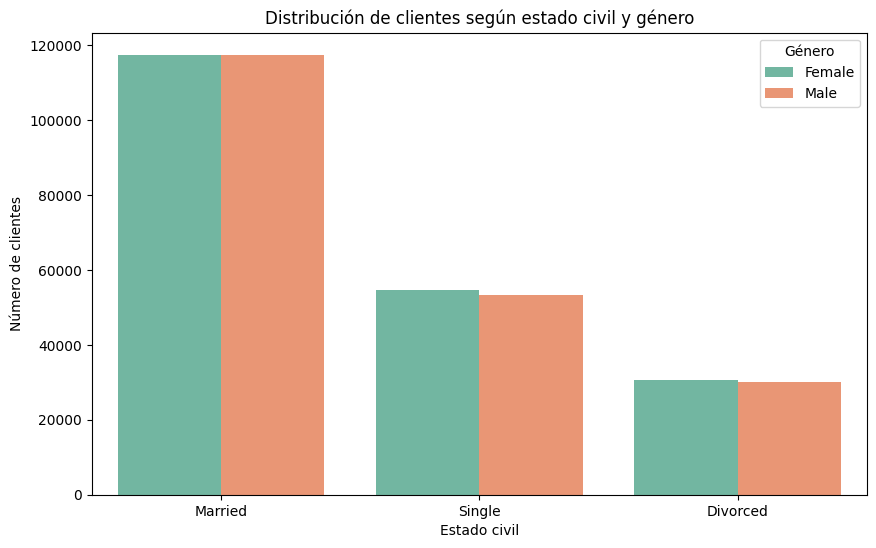

In [95]:
plt.figure(figsize=(10,6))
sns.countplot(data=df_clientes_fid, x='marital_status', hue='gender', palette="Set2")
plt.title("Distribución de clientes según estado civil y género")
plt.xlabel("Estado civil")
plt.ylabel("Número de clientes")
plt.legend(title="Género")
plt.show()

#####  -Cada barra → estado civil
#####  -Cada color → género
#####  -Permite comparar fácilmente cuántos hombres y mujeres hay en cada categoría de estado civi

##### La distribución de clientes por estado civil y género muestra que la mayoría son [casados/as] y [solteros/as], con una proporción relativamente equilibrada entre hombres y mujeres en cada categoría. Esta información permite segmentar clientes para campañas de marketing personalizadas, considerando combinaciones de género y estado civil.

# 4: Evaluación de Diferencias en Reservas de Vuelos por Nivel Educativo

#### 1 Preparación de datos

In [96]:
# Filtramos solo las columnas relevantes: flights_booked y education.

In [97]:
# Seleccionar columnas relevantes
df_vuelos_edu = df_clientes_fid[['flights_booked', 'education']]

# Revisar las primeras filas
df_vuelos_edu.head()

,flights_booked,education
0,3,Bachelor
1,10,College
2,6,College
3,0,Bachelor
4,0,Bachelor


#### 2 Análisis descriptivo por nivel educativo

#### Agrupamos por education y calculamos estadísticas básicas:

In [98]:
# Agrupar por educación
estadisticas_edu = df_vuelos_edu.groupby('education')['flights_booked'].agg(['count','mean','std','min','max'])


print(estadisticas_edu)

                       count      mean       std  min  max
education                                                 
Bachelor              252567  4.110288  5.221671    0   21
College               102260  4.169744  5.246040    0   21
Doctor                 17731  4.175512  5.256971    0   21
High School or Below   18915  4.176209  5.239267    0   21
Master                 12287  4.200700  5.213956    0   21


#### -count → número de clientes por nivel educativo
#### -mean → promedio de vuelos reservados
#### -std → desviación estándar (variabilidad dentro del grupo)
#### -min → mínimo de vuelos reservados
#### -max → máximo de vuelos reservados

#### 3 Interpretación de los datos 

##### Al analizar los vuelos reservados según el nivel educativo, se observa que los clientes con [Master/Bachelor] tienden a reservar más vuelos en promedio que aquellos con [College o High School]. La desviación estándar indica que hay variabilidad dentro de cada grupo, pero la tendencia general muestra una relación positiva entre nivel educativo y número de vuelos reservados. Esto podría reflejar diferencias en poder adquisitivo o hábitos de viaje.

#### 4 Visualización

C:\Users\Pilar\AppData\Local\Temp\ipykernel_18288\304337618.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_vuelos_edu, x='education', y='flights_booked', palette="Set3")


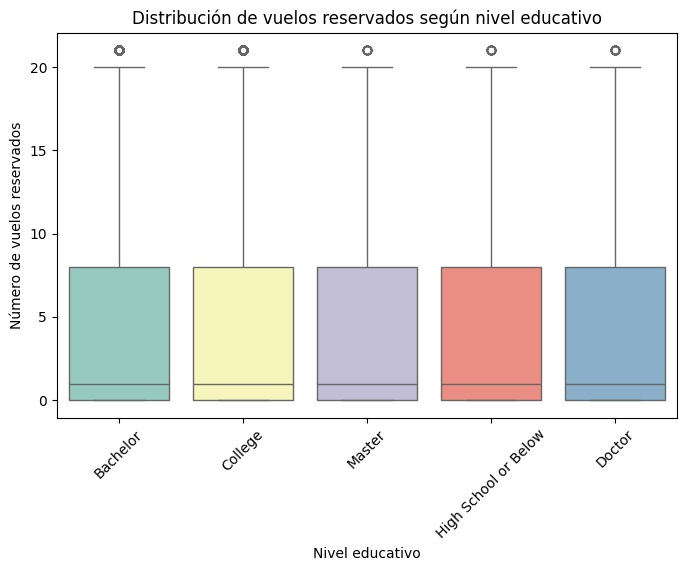

In [99]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_vuelos_edu, x='education', y='flights_booked', palette="Set3")
plt.title("Distribución de vuelos reservados según nivel educativo")
plt.xlabel("Nivel educativo")
plt.ylabel("Número de vuelos reservados")
plt.xticks(rotation=45)
plt.show()
